Processing noise power 13.2 from /ceph/dwong/work/threshold/noise_13.2/traces_energy_0.zst


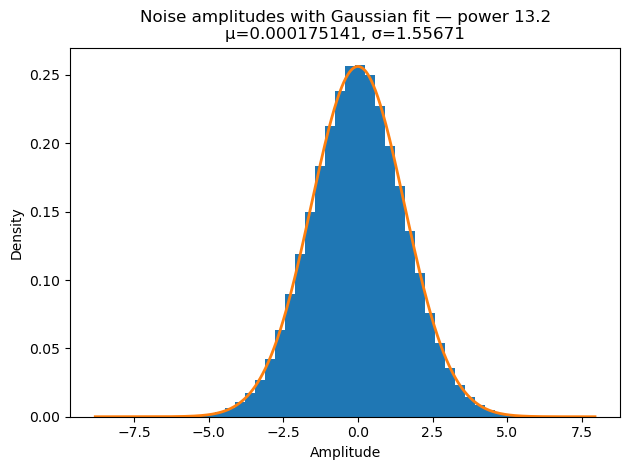

Processing noise power 17.2 from /ceph/dwong/work/threshold/noise_17.2/traces_energy_0.zst


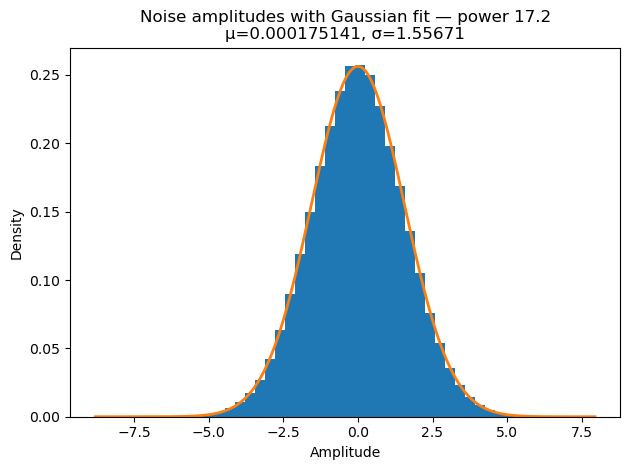

Processing noise power 21.2 from /ceph/dwong/work/threshold/noise_21.2/traces_energy_0.zst


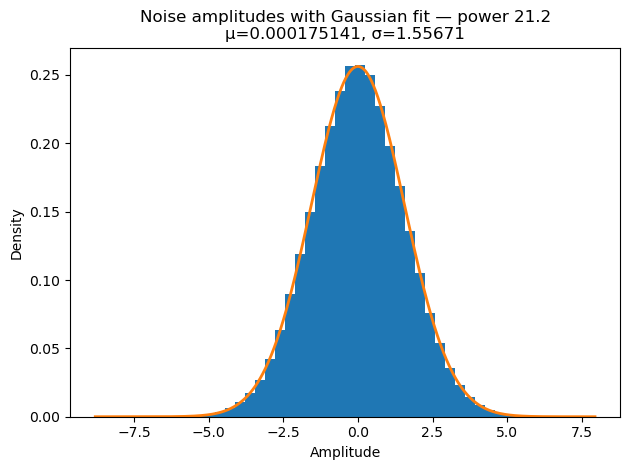

Processing noise power 25.2 from /ceph/dwong/work/threshold/noise_25.2/traces_energy_0.zst


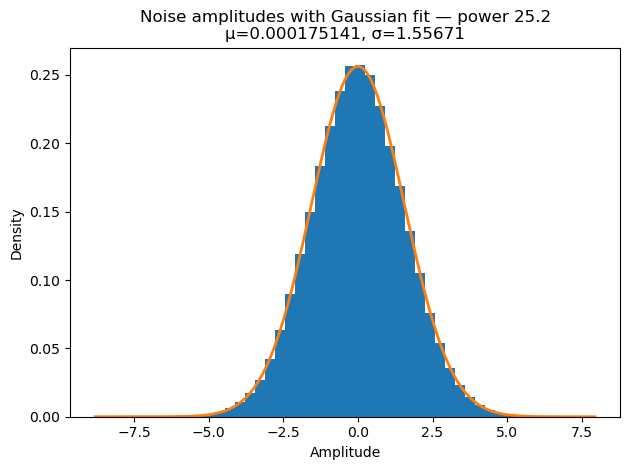

Processing noise power 29.2 from /ceph/dwong/work/threshold/noise_29.2/traces_energy_0.zst


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import zstandard as zstd

from wk27.OptimumFilter import OptimumFilter

# ---------- zstd loader (FIXED) ----------
def load_traces_from_zstd(input_path, n_traces, dtype=np.float16, trace_shape=(56, 150000)) -> np.ndarray:
    """
    Load a list of numpy arrays (traces) from a compressed Zstandard (.zst) file
    and return a single stacked ndarray of shape (n_traces, *trace_shape).
    """
    def unshuffle_bytes(data: bytes, dtype=np.float16, shape=( 56, 150000)) -> np.ndarray:
        itemsize = np.dtype(dtype).itemsize
        num_elements = np.prod(shape)
        reshaped = np.frombuffer(data, dtype=np.uint8).reshape(itemsize, num_elements).T
        unshuffled = reshaped.reshape(-1)
        return unshuffled.view(dtype).reshape(shape)

    decompressor = zstd.ZstdDecompressor()
    with open(input_path, 'rb') as f:
        compressed_content = f.read()

    trace_size_bytes = np.prod(trace_shape) * np.dtype(dtype).itemsize
    expected_size = n_traces * trace_size_bytes

    # IMPORTANT: provide max_output_size because content size is not in frame header
    decompressed = decompressor.decompress(compressed_content, max_output_size=expected_size)

    if len(decompressed) != expected_size:
        raise ValueError(
            f"Decompressed size ({len(decompressed)}) does not match expected size ({expected_size})"
        )

    traces = []
    for i in range(n_traces):
        start = i * trace_size_bytes
        end = start + trace_size_bytes
        trace_bytes = decompressed[start:end]
        trace = unshuffle_bytes(trace_bytes, dtype=dtype, shape=trace_shape)
        traces.append(trace)

    return np.stack(traces).astype(np.float32)

# ---------- user inputs ----------
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
OF_psd_path = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
fs = 3_906_250  # Hz

base_dir = "/ceph/dwong/work/threshold"
trace_relpath = "traces_energy_0.zst"
trace_shape = (56, 150000)  # (channels, samples)
sub_start_ch = 45           # channels >= this are summed for the sub-channel

# >>> Set this to the actual number of traces per file <<<
N_TRACES = 200  # <-- adjust to your true value

# Noise powers: 13.2, 17.2, ..., 53.2
noise_powers = []
p = 13.2
while p <= 53.2 + 1e-6:
    noise_powers.append(round(p, 1))
    p += 4.0

# ---------- build OptimumFilter once ----------
noise_psd = np.load(OF_psd_path)
worker = OptimumFilter(sub_template, noise_psd, fs)

# ---------- run loop ----------
summary = []
for power in noise_powers:
    zst_path = os.path.join(base_dir, f"noise_{power:.1f}", trace_relpath)
    print(f"Processing noise power {power:.1f} from {zst_path}")

    traces = load_traces_from_zstd(
        zst_path,
        n_traces=N_TRACES,
        dtype=np.float16,
        trace_shape=trace_shape,
    )
    # traces shape: (n_traces, n_channels, n_samples)

    # Build "sub-channel" by summing channels >= sub_start_ch
    sub_traces = traces[:, sub_start_ch:, :].sum(axis=1)  # (n_traces, n_samples)

    # Flatten to one long 1D noise trace
    noise_trace = sub_traces.reshape(-1).astype(np.float32)

    # Slide to get amplitudes
    amps, _ = worker.sliding_fit(
        noise_trace,
        hop=1,
        reanchor_every=None,
        chisq_mode="none",
    )

    # Fit Gaussian to amplitudes
    mu, sigma = norm.fit(amps)

    # Histogram + Gaussian curve
    counts, bins, patches = plt.hist(amps, bins=50, density=True)
    x = np.linspace(float(np.min(amps)), float(np.max(amps)), 1000)
    pdf = norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, linewidth=2)
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title(
        f"Noise amplitudes with Gaussian fit — power {power:.1f}\n"
        f"μ={mu:.6g}, σ={sigma:.6g}"
    )
    plt.tight_layout()
    plt.show()

    summary.append({
        "noise_power": float(power),
        "mu": float(mu),
        "sigma": float(sigma),
        "n_amps": int(len(amps)),
    })

# ---------- print summary ----------
print("\n=== Summary (per noise power) ===")
w_power = max(len(f"{s['noise_power']:.1f}") for s in summary)
w_sigma = 12
w_mu = 12
print(f"{'power':{w_power}}  {'mu':>{w_mu}}  {'sigma':>{w_sigma}}  n_amps")
for s in summary:
    print(
        f"{s['noise_power']:{w_power}.1f}  "
        f"{s['mu']:>{w_mu}.6g}  {s['sigma']:>{w_sigma}.6g}  {s['n_amps']:>6d}"
    )


Processing noise power 13.2 from /ceph/dwong/work/threshold/noise_13.2/traces_energy_0.zst


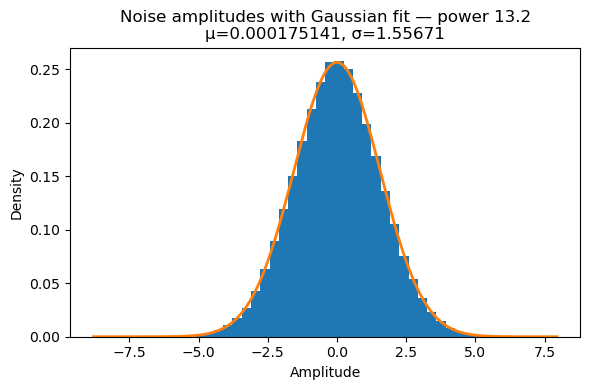

Processing noise power 17.2 from /ceph/dwong/work/threshold/noise_17.2/traces_energy_0.zst


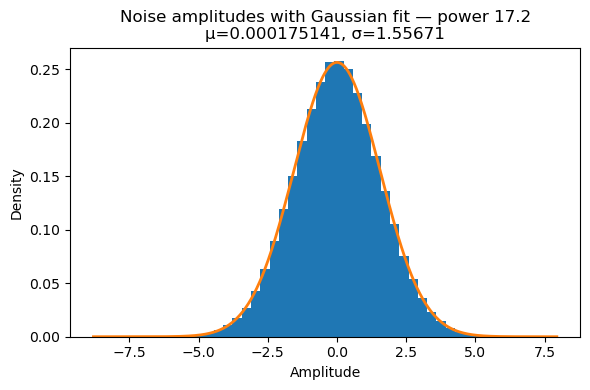

Processing noise power 21.2 from /ceph/dwong/work/threshold/noise_21.2/traces_energy_0.zst


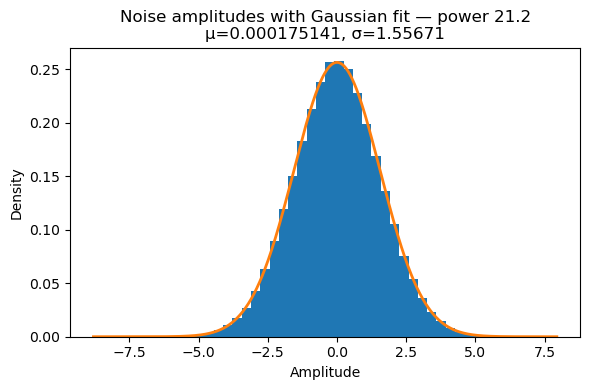

Processing noise power 25.2 from /ceph/dwong/work/threshold/noise_25.2/traces_energy_0.zst


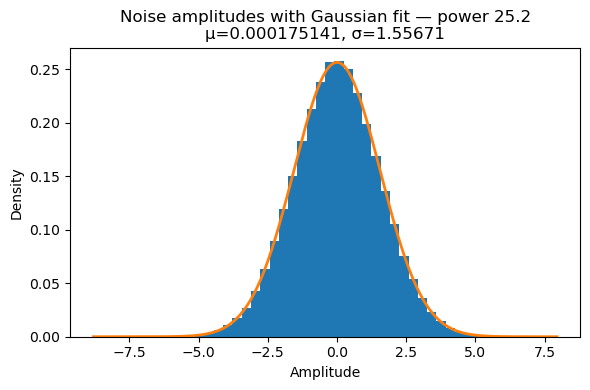

Processing noise power 29.2 from /ceph/dwong/work/threshold/noise_29.2/traces_energy_0.zst


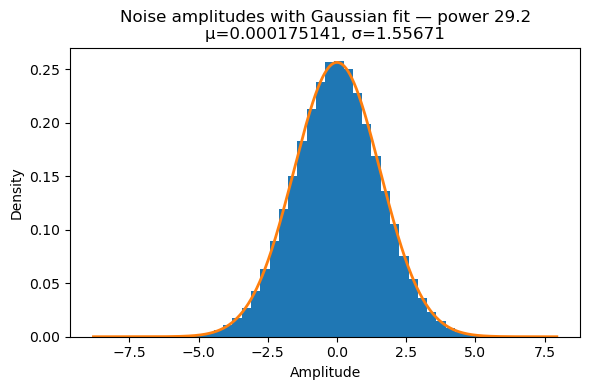

Processing noise power 33.2 from /ceph/dwong/work/threshold/noise_33.2/traces_energy_0.zst


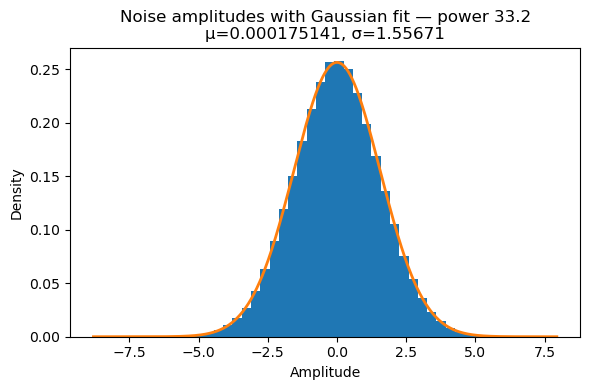

Processing noise power 37.2 from /ceph/dwong/work/threshold/noise_37.2/traces_energy_0.zst


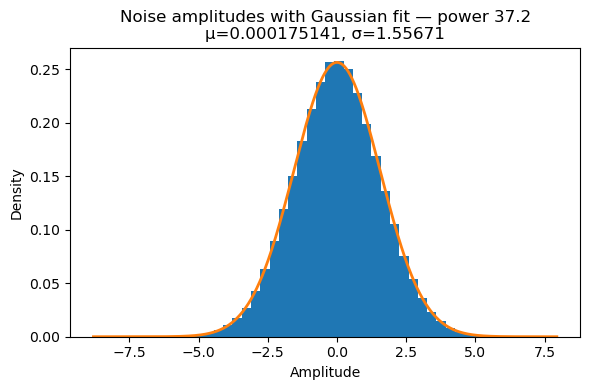

Processing noise power 41.2 from /ceph/dwong/work/threshold/noise_41.2/traces_energy_0.zst


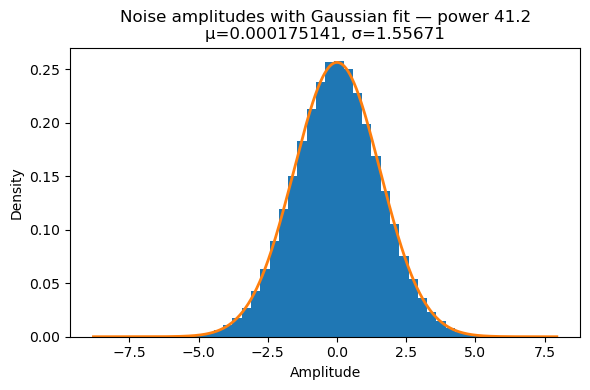

Processing noise power 45.2 from /ceph/dwong/work/threshold/noise_45.2/traces_energy_0.zst


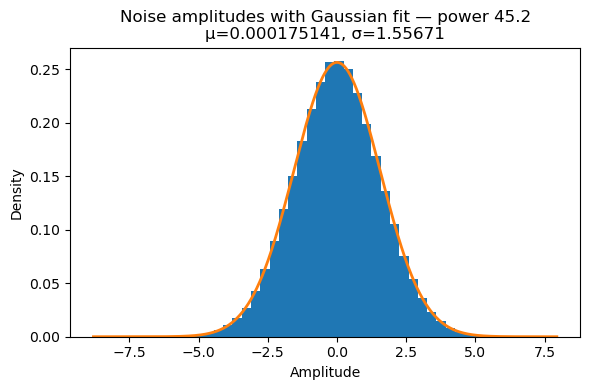

Processing noise power 49.2 from /ceph/dwong/work/threshold/noise_49.2/traces_energy_0.zst


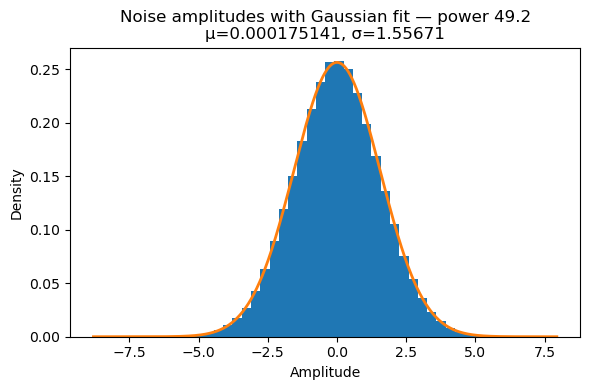

Processing noise power 53.2 from /ceph/dwong/work/threshold/noise_53.2/traces_energy_0.zst


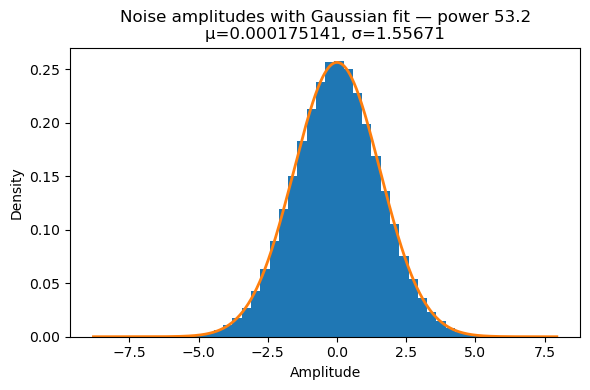


=== Summary (per noise power) ===
power            mu         sigma  n_amps
13.2   0.000175141       1.55671  29967233
17.2   0.000175141       1.55671  29967233
21.2   0.000175141       1.55671  29967233
25.2   0.000175141       1.55671  29967233
29.2   0.000175141       1.55671  29967233
33.2   0.000175141       1.55671  29967233
37.2   0.000175141       1.55671  29967233
41.2   0.000175141       1.55671  29967233
45.2   0.000175141       1.55671  29967233
49.2   0.000175141       1.55671  29967233
53.2   0.000175141       1.55671  29967233


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import zstandard as zstd

from wk27.OptimumFilter import OptimumFilter

# ---------- zstd loader (FIXED) ----------
def load_traces_from_zstd(input_path, n_traces, dtype=np.float16, trace_shape=(56, 150000)) -> np.ndarray:
    """
    Load a list of numpy arrays (traces) from a compressed Zstandard (.zst) file
    and return a single stacked ndarray of shape (n_traces, *trace_shape).
    """
    def unshuffle_bytes(data: bytes, dtype=np.float16, shape=(56, 150000)) -> np.ndarray:
        itemsize = np.dtype(dtype).itemsize
        num_elements = np.prod(shape)
        reshaped = np.frombuffer(data, dtype=np.uint8).reshape(itemsize, num_elements).T
        unshuffled = reshaped.reshape(-1)
        return unshuffled.view(dtype).reshape(shape)

    decompressor = zstd.ZstdDecompressor()
    with open(input_path, 'rb') as f:
        compressed_content = f.read()

    trace_size_bytes = np.prod(trace_shape) * np.dtype(dtype).itemsize
    expected_size = n_traces * trace_size_bytes

    # IMPORTANT: provide max_output_size because content size is not in frame header
    decompressed = decompressor.decompress(compressed_content, max_output_size=expected_size)

    if len(decompressed) != expected_size:
        raise ValueError(
            f"Decompressed size ({len(decompressed)}) does not match expected size ({expected_size})"
        )

    traces = []
    for i in range(n_traces):
        start = i * trace_size_bytes
        end = start + trace_size_bytes
        trace_bytes = decompressed[start:end]
        trace = unshuffle_bytes(trace_bytes, dtype=dtype, shape=trace_shape)
        traces.append(trace)

    return np.stack(traces).astype(np.float32)

# ---------- user inputs ----------
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
OF_psd_path = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
fs = 3_906_250  # Hz

base_dir = "/ceph/dwong/work/threshold"
trace_relpath = "traces_energy_0.zst"
trace_shape = (56, 150000)  # (channels, samples)
sub_start_ch = 45           # channels >= this are summed for the sub-channel

# >>> Set this to the actual number of traces per file <<<
N_TRACES = 200  # <-- adjust to your true value

# Noise powers: 13.2, 17.2, ..., 53.2
noise_powers = []
p = 13.2
while p <= 53.2 + 1e-6:
    noise_powers.append(round(p, 1))
    p += 4.0

# ---------- build OptimumFilter once ----------
noise_psd = np.load(OF_psd_path)
worker = OptimumFilter(sub_template, noise_psd, fs)

# ---------- run loop ----------
summary = []
for power in noise_powers:
    zst_path = os.path.join(base_dir, f"noise_{power:.1f}", trace_relpath)
    print(f"Processing noise power {power:.1f} from {zst_path}")

    traces = load_traces_from_zstd(
        zst_path,
        n_traces=N_TRACES,
        dtype=np.float16,
        trace_shape=trace_shape,
    )
    # traces shape: (n_traces, n_channels, n_samples)

    # Build "sub-channel" by summing channels >= sub_start_ch
    sub_traces = traces[:, sub_start_ch:, :].sum(axis=1)  # (n_traces, n_samples)

    # Flatten to one long 1D noise trace
    noise_trace = sub_traces.reshape(-1).astype(np.float32)

    # Slide to get amplitudes
    amps, _ = worker.sliding_fit(
        noise_trace,
        hop=1,
        reanchor_every=None,
        chisq_mode="none",
    )

    # Optionally remove non-finite values before fitting
    amps = amps[np.isfinite(amps)]

    # Fit Gaussian to amplitudes (per noise power)
    mu, sigma = norm.fit(amps)

    # --- Plot for THIS noise power only ---
    plt.figure(figsize=(6, 4))  # <--- ensure a fresh figure per iteration
    counts, bins, patches = plt.hist(amps, bins=50, density=True)
    x = np.linspace(float(np.min(amps)), float(np.max(amps)), 1000)
    pdf = norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, linewidth=2)
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title(
        f"Noise amplitudes with Gaussian fit — power {power:.1f}\n"
        f"μ={mu:.6g}, σ={sigma:.6g}"
    )
    plt.tight_layout()
    plt.show()
    # plt.close()  # optionally close to save memory in long runs

    summary.append({
        "noise_power": float(power),
        "mu": float(mu),
        "sigma": float(sigma),
        "n_amps": int(len(amps)),
    })

# ---------- print summary ----------
print("\n=== Summary (per noise power) ===")
w_power = max(len(f"{s['noise_power']:.1f}") for s in summary)
w_sigma = 12
w_mu = 12
print(f"{'power':{w_power}}  {'mu':>{w_mu}}  {'sigma':>{w_sigma}}  n_amps")
for s in summary:
    print(
        f"{s['noise_power']:{w_power}.1f}  "
        f"{s['mu']:>{w_mu}.6g}  {s['sigma']:>{w_sigma}.6g}  {s['n_amps']:>6d}"
    )
